pystran - Python package for structural analysis with trusses and beams.

(C) 2025, Petr Krysl, pkrysl@ucsd.edu
`
# Three-bar truss example

## Problem description:

Structure consisting of three truss members. This tutorial mirrors the tutorial
`01_three_bars_tut`, but uses alternative (mixed integer and string) identifiers for
creating the model.

Displacements and internal forces are provided in the reference.

## References

Three-bar example on page 32 from the book Analysis of Geometrically Nonlinear
Structures Second Edition by Robert Levy and William R. Spillers.

The following imports are necessary for the example to work.


In [41]:
from numpy.linalg import norm
from numpy import concatenate, dot
import context
from pystran import model
from pystran import section
from pystran import geometry
from pystran import truss
from pystran import plots

Now we create the model `m`, which is a dictionary that contains all the
constituent parts of the system. The model is created for a planar structure
(2). The deformation is assumed to occur in the plane `x-z`.


In [42]:
m = model.create(2)
freedoms = m["freedoms"]

There are four joints. Note that the coordinates are supplied without
physical units. Everything needs to be provided in consistent units (here SI with lengths in meters). Note
that the joints are identified by names instead of by numbers, and the
coordinates are supplied either as lists of coordinates (i.e. in square
brackets) or as tuples (i.e. in round brackets). Also, joint "A" is assigned
to a variable. Note well: we show this just to illustrate the flexibility, there is no requirement either way.


In [43]:
jA = model.add_joint(m, "A", [10.0, 20.0])
model.add_joint(m, "B", [0.0, 20.0])
model.add_joint(m, "C", [0.0, 10.0])
model.add_joint(m, "D", (+10.0, 0.0))

{'jid': 'D', 'coordinates': array([10.,  0.])}

The material parameters and the cross sectional area of the
bars.


In [44]:
E = 30000000.0
A = 0.65700000

These parameters are used to create a section.


In [45]:
s1 = section.truss_section("steel", E, A)

The truss members are added to the model. The connectivity is provided as
lists of `[start, end]` joints. The section is also provided. Note that one
member is called "m1" and the other two are numbered. Also, the connectivity
is supplied in one case as tuple, in the other two cases as lists. (Again, to illustrate the flexibility of the model definition.)


In [46]:
model.add_truss_member(m, "m1", ["A", "B"], s1)
model.add_truss_member(m, 2, ("A", "C"), s1)
model.add_truss_member(m, 3, ["A", "D"], s1)

{'mid': 3,
 'connectivity': ['A', 'D'],
 'section': {'name': 'steel',
  'E': 30000000.0,
  'rho': 0.0,
  'CTE': 0.0,
  'A': 0.657}}

The supports are added to the model. The pinned supports are added to the
joints 2, 3, and 4, by constraining both x and z displacements to zero.
Here `d` takes on the values 0 (meaning displacement along x), and 1 (z displacement).


In [47]:
for i in ["B", "C", "D"]:
    for d in range(2):
        model.add_support(m["joints"][i], d)

At this point we can visualize the structure. We show all members, member
orientations, and the joint numbers.


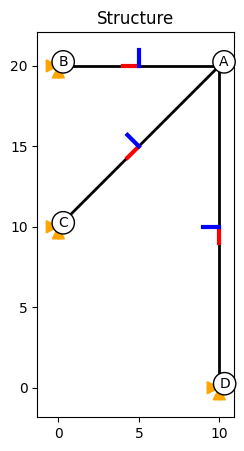

In [48]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_member_orientation(m)
plots.plot_joint_ids(m)
plots.plot_translation_supports(m)
ax.set_title("Structure")
plots.show(m)

At this point we can visualize the supports. The translation supports are
shown with arrow heads.


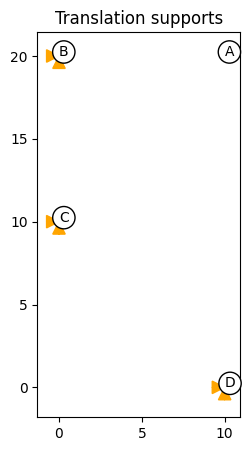

In [49]:
ax = plots.setup(m)
plots.plot_joint_ids(m)
plots.plot_translation_supports(m)
ax.set_title("Translation supports")
plots.show(m)

Loads are added to the joint 1. The loads are provided as [x, z] components (0 or 1).


In [50]:
model.add_load(jA, 0, -10000.0)
model.add_load(jA, 1, -10000.0 / 2.0)

The model is shown graphically, members are displayed with the member numbers attached.
The applied forces are also shown.


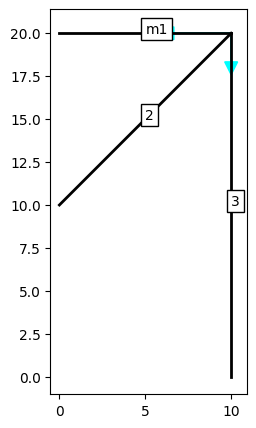

In [51]:
plots.setup(m)
plots.plot_members(m)
plots.plot_applied_forces(m, 1 / 3000.0)
plots.plot_member_ids(m)
plots.show(m)

The degrees of freedom are numbered, first the unknowns (free) degrees of
freedom, then the known (prescribed) degrees of freedom.


In [52]:
model.number_dofs(m)
print("Total Degrees of Freedom = ", m["ntotaldof"])
print("Free Degrees of Freedom = ", m["nfreedof"])

Total Degrees of Freedom =  8
Free Degrees of Freedom =  2


The model is solved.  This means that the displacements are calculated  from
the balance of the joints.


In [53]:
model.solve_statics(m)

The displacements at all the joints are printed.


In [54]:
for j in m["joints"].values():
    print(j["displacements"])

[-0.00333259 -0.00159162]
[0. 0.]
[0. 0.]
[0. 0.]


The displacements are compared to the reference values from the book.


In [55]:
if norm(jA["displacements"] - [-0.0033325938, -0.001591621]) > 1.0e-3:
    raise ValueError("Displacement calculation error")
print("Displacement calculation OK")

Displacement calculation OK


The forces in the bars can be calculated using the strain-displacement matrix
to compute the strain, from which we can evaluate the force.


In [56]:
for b in m["truss_members"].values():
    connectivity = b["connectivity"]
    i, j = m["joints"][connectivity[0]], m["joints"][connectivity[1]]
    e_x, e_z, h = geometry.member_2d_geometry(i, j)
    B = truss.truss_strain_displacement(e_x, h)
    u = concatenate((i["displacements"], j["displacements"]))
    eps = dot(B, u)
    print("Bar " + str(connectivity) + " force = ", E * A * eps[0])

Bar ['A', 'B'] force =  -6568.542494923801
Bar ('A', 'C') force =  -4852.8137423857015
Bar ['A', 'D'] force =  -1568.5424949238025


The forces in the bars can be simply calculated using the `truss_axial_force`
function. That function does what was described in the loop above.


In [57]:
for b in m["truss_members"].values():
    connectivity = b["connectivity"]
    i, j = m["joints"][connectivity[0]], m["joints"][connectivity[1]]
    N = truss.truss_axial_force(b, i, j, 0.0)
    print("N = ", N)

N =  -6568.542494923801
N =  -4852.8137423857015
N =  -1568.5424949238025


These are the reference values of the forces from the book.


In [58]:
print("Reference forces: ", -0.656854250e4, -0.48528137e4, -0.15685425e4)

Reference forces:  -6568.5425 -4852.8137 -1568.5425


The solution is visualized with the deformed shape.


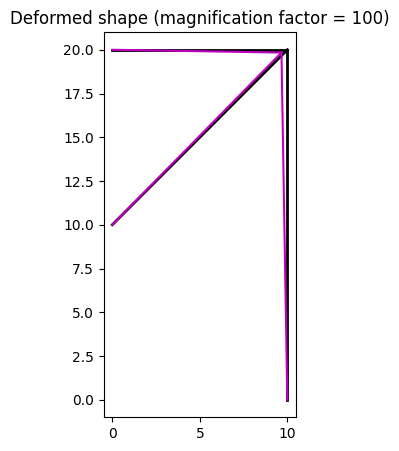

In [59]:
plots.setup(m)
plots.plot_members(m)
ax = plots.plot_deformations(m, 100.0)
ax.set_title("Deformed shape (magnification factor = 100)")
plots.show(m)

The solution is further visualized with graphical representation of the
internal (axial) forces.


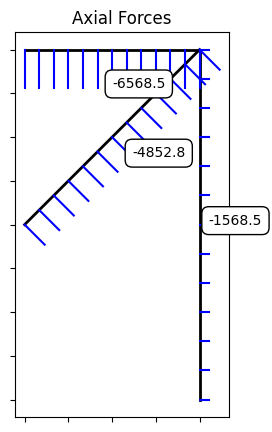

In [60]:
plots.setup(m)
plots.plot_members(m)
ax = plots.plot_axial_forces(m, 1 / 3000.0)
ax.set_title("Axial Forces")
plots.show(m)